In [6]:
import numpy as np
import pandas as pd
import os 
from scipy.stats import expon, uniform, beta
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from time import time
from copy import deepcopy
from itertools import product
from functools import partial
import networkx as nx
from sklearn.metrics import mean_absolute_error

from InfluenceDiffusion.Graph import Graph
from InfluenceDiffusion.influence_models import LTM
from InfluenceDiffusion.estimation_models.OptimEstimation import GLTWeightEstimator
from InfluenceDiffusion.weight_samplers import make_random_weights_with_indeg_constraint, \
    make_random_weights_with_fixed_indeg

os.chdir("/Users/amkagan/Desktop/gltm_experiments")

from utils.trace_utils import trace_train_test_split, make_report_traces
from utils.utils import plot_distribution, RMAE, make_distrib_name
from utils.model_evaluation_utils import compare_metric_over_bins, make_heatmap

## Define graph & sample traces

In [14]:
n_nodes = 100
rewire_p = 0.2
init_k = 10

test_ratio = 0.25

random_state = 1

g = nx.watts_strogatz_graph(n_nodes, k=init_k, p=rewire_p, seed=random_state)
g = Graph(g.edges)

true_weights = make_random_weights_with_indeg_constraint(g, random_state=random_state)
# true_weights = generate_edge_weights_with_fixed_avg_indeg(g, avg_indeg=inv_indeg_coef, noise_eps=noise_eps)

g.set_weights(true_weights)

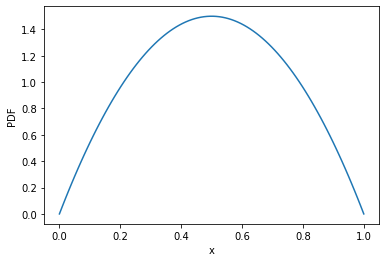

In [21]:
a, b = 2, 2
true_distrib = beta(a, b) #mean is a / (a + b)
plot_distribution(true_distrib)
mean = true_distrib.mean()

Avg number of activated nodes: 7.49. Std: 4.55


100%|██████████████████████████| 1000/1000 [00:02<00:00, 372.15it/s]


Proportion of edges participated in <= 5 traces: 0.0


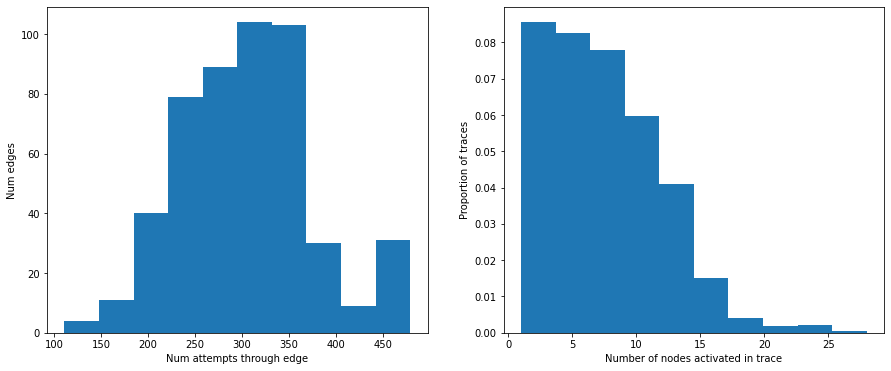

In [19]:
n_traces = 1000
max_seed_size = 10
seed_size_range=range(1, max_seed_size + 1)

true_ltm = LTM(g, threshold_generator=true_distrib, random_state=random_state)
traces = true_ltm.sample_traces(n_traces=n_traces, seed_size_range=seed_size_range)
_ = make_report_traces(traces)

train_traces, test_traces = trace_train_test_split(traces, test_ratio=test_ratio)
len(train_traces), len(test_traces)

## 1. Experiments
### 1.1 Beta distribution comparison

In [145]:
save_name = \
f"WS_a{a}_b{b}_{n_nodes}_seed_{max_seed_size}_rewire_p_{rewire_p}_init_k_{init_k}_traces_{n_traces}_random_state_{random_state}"

In [134]:
def RMSE(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

In [149]:
def weight_estimation_from_distrib(distrib, g=g, traces=train_traces):
    vertex_2_distrib = {vertex: distrib for vertex in g.get_vertices()}
    ltm_estimator = GLTWeightEstimator(g, vertex_2_distrib=vertex_2_distrib, n_jobs=8)
    weights = ltm_estimator.fit(traces).weights_
    ll = -ltm_estimator._compute_total_nll(weights)
    return weights, ll

In [136]:
a_range = np.linspace(1, 3, 9)
b_range = np.linspace(1, 3, 9)

ab_pairs = np.array(list(product(a_range, b_range)))
beta_distribs = [beta(*ab_pair) for ab_pair in ab_pairs]

In [123]:
weight_ll_pairs = list(tqdm(map(weight_estimation_from_distrib, beta_distribs), 
                             total=len(beta_distribs)))
weights_list, lls = zip(*weight_ll_pairs)

100%|███████████████████████████████| 81/81 [01:23<00:00,  1.03s/it]


In [96]:
# np.save(f"saved_results/beta_ab_weights_{save_name}", weights_list)

In [146]:
# weights_list = np.load(f"saved_results/beta_ab_weights_{save_name}.npy")

In [92]:
def compute_test_ll(weights, distrib, g=g, test_traces=test_traces):
    vertex_2_distrib = {vertex: distrib for vertex in g.get_vertices()}
    ltm_estimator = GLTWeightEstimator(g, vertex_2_distrib=vertex_2_distrib, n_jobs=8)
    ltm_estimator._pre_fit(test_traces)
    return -ltm_estimator._compute_total_nll(weights)

In [93]:
test_lls = [compute_test_ll(weights=weights, distrib=distrib) 
            for weights, distrib in tqdm(zip(weights_list, beta_distribs))]

81it [00:18,  4.30it/s]


In [ ]:
a, b = ab_pairs[np.argmax(test_lls)]
print(f"Test Log-likelihoods of Beta(a, b) distributions with true a = {a}, b = {b}")
make_heatmap(test_lls, ab_pairs, title=None)
plt.savefig("figures/beta_cv.png", dpi=200)

Test Log-likelihoods of Beta(a, b) distributions with true a = 2.0, b = 2.0


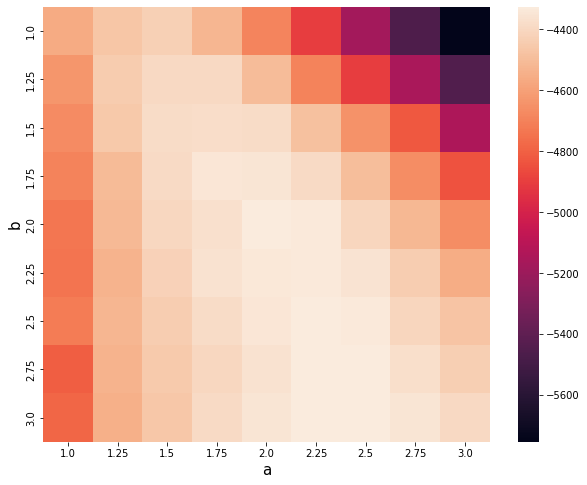

In [105]:
a, b = ab_pairs[np.argmax(test_lls)]
print(f"Test Log-likelihoods of Beta(a, b) distributions with true a = {a}, b = {b}")
make_heatmap(test_lls, ab_pairs, title=None)
plt.savefig("figures/beta_cv.png", dpi=200)

## Compute spread for spected (a, b) pairs

In [150]:
selected_ab_pairs = [(2, 2), (2, 1), (1, 1), (3, 1)]
beta_distribs = [beta(*ab_pair) for ab_pair in selected_ab_pairs]

weight_ll_pairs = list(tqdm(map(weight_estimation_from_distrib, beta_distribs), 
                            total=len(beta_distribs)))
weights_list, lls = zip(*weight_ll_pairs)
ab_2_weight = {tuple(ab_pair): weights for ab_pair, weights in zip(selected_ab_pairs, weights_list)}

100%|█████████████████████████████████| 4/4 [00:09<00:00,  2.38s/it]


In [151]:
num_runs_per_seed = 1000

def compute_avg_spread_over_seeds(distrib, weights, seeds, g, 
                                  num_runs_per_seed=num_runs_per_seed, with_std=False, n_jobs=None):
    g_copy = deepcopy(g)
    g_copy.set_weights(weights)
    distrib_dict = {v: distrib for v in g.get_vertices()}
    model = GLTM(g_copy, distrib_dict, check_init=True, n_jobs=n_jobs)
    results = [model.estimate_spread(seed, n_runs=num_runs_per_seed, with_std=with_std) 
               for seed in tqdm(seeds, position=0)]
    return np.stack(results)

In [148]:
true_test_spread = compute_avg_spread_over_seeds(distrib=true_distrib, weights=true_weights, seeds=test_seeds, g=g)

100%|█████████████████████████████| 250/250 [00:45<00:00,  5.55it/s]


In [156]:
selected_pred_spreads = [compute_avg_spread_over_seeds(distrib=beta(*ab_pair), 
                                                                  weights=ab_2_weight[ab_pair], 
                                                                  seeds=test_seeds, g=g,
                                                                  n_jobs=8) 
                         for ab_pair in selected_ab_pairs]

100%|█████████████████████████████| 250/250 [01:03<00:00,  3.96it/s]


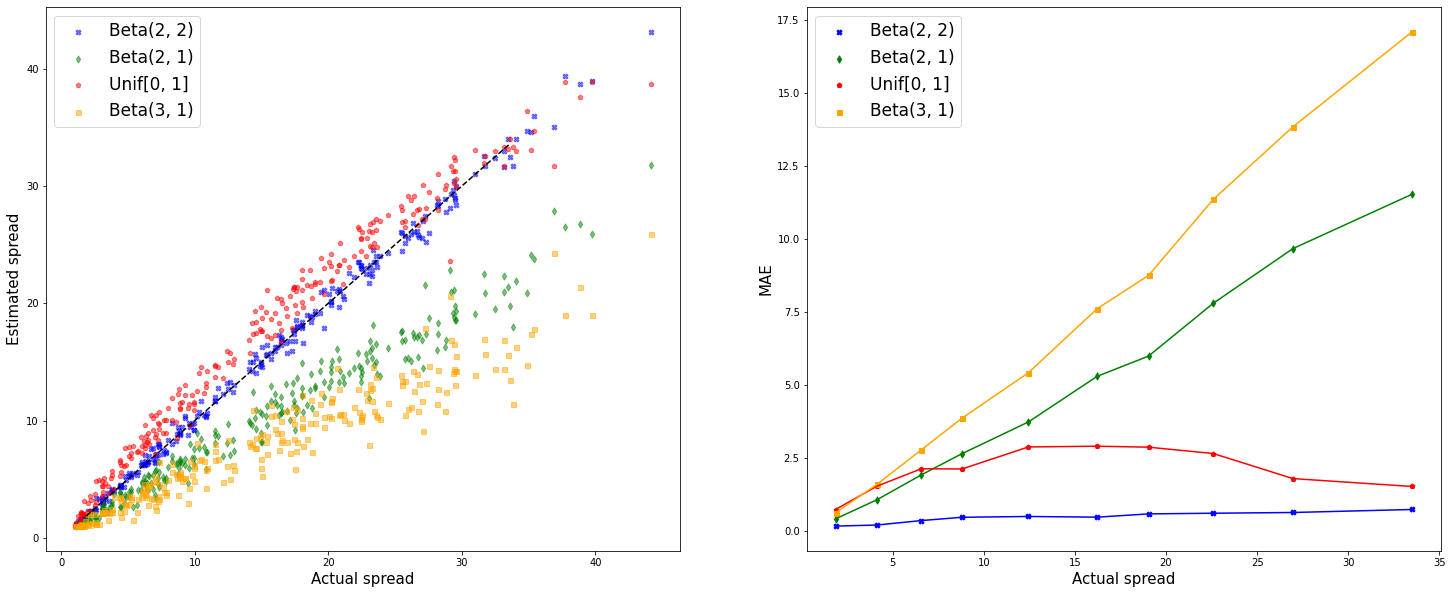

In [158]:
ab_legend_pairs = ["Unif[0, 1]" if (a == 1 and b == 1) else f"Beta({a}, {b})" 
                   for (a, b) in selected_ab_pairs ]
compare_metric_over_bins(true_test_spread, selected_pred_spreads, metric=mean_absolute_error,
                         pred_names=ab_legend_pairs, bins=10,
                         markersize=25, colors=["b", "g", "r", "orange"])

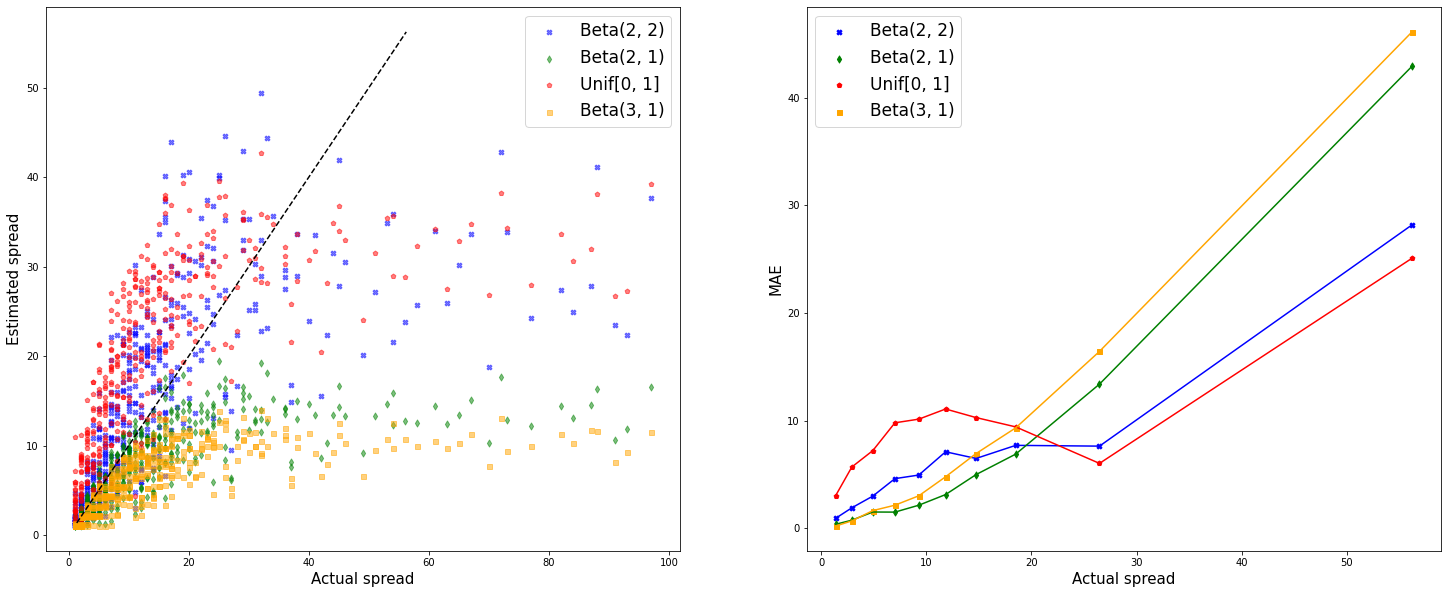

In [52]:
ab_legend_pairs = ["Unif[0, 1]" if (a == 1 and b == 1) else f"Beta({a}, {b})" 
                   for (a, b) in selected_ab_pairs ]

compare_metric_over_bins(true_test_spread, selected_pred_spreads, metric=mean_absolute_error,
                         pred_names=ab_legend_pairs, bins=10,
                         markersize=25, colors=["b", "g", "r", "orange"])